# Librerías

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_iris
import copy

# Definición de la red

In [12]:
# Vamos a añadir una capa lineal oculta con función de activación ReLU
class IrisMLP(nn.Module):
    def __init__(self, hidden_dim: int = 16):
        super().__init__()
        self.fc1 = nn.Linear(4, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 3)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.relu(self.fc1(x))   # (B, 16)
        logits = self.fc2(h)         # (B, 3)
        return logits

# Dataset y Dataloader

In [13]:
class IrisDataset(Dataset):
    def __init__(self):
        data = load_iris()
        self.X = torch.tensor(
            data.data, dtype=torch.float32
        )  # (150, 4)
        self.y = torch.tensor(
            data.target, dtype=torch.long
        )  # (150,)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [14]:
full_iris_dataset = IrisDataset()
train_dataset, test_dataset, val_dataset = torch.utils.data.random_split(full_iris_dataset, [0.7, 0.2, 0.1], generator=torch.Generator().manual_seed(42))

In [15]:
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Ejercicio 1

Haz el entrenamiento de la red durante 100 epochs, reportando el loss de entrenamiento en cada epoch. Finalmente dibuja la gráfica del loss de entrenamiento a lo largo de las epochs.

Epoch 001/100 - Train loss: 1.1094
Epoch 002/100 - Train loss: 0.9911
Epoch 003/100 - Train loss: 0.8818
Epoch 004/100 - Train loss: 0.7857
Epoch 005/100 - Train loss: 0.7103
Epoch 006/100 - Train loss: 0.6322
Epoch 007/100 - Train loss: 0.5798
Epoch 008/100 - Train loss: 0.5442
Epoch 009/100 - Train loss: 0.4952
Epoch 010/100 - Train loss: 0.4755
Epoch 011/100 - Train loss: 0.4686
Epoch 012/100 - Train loss: 0.4298
Epoch 013/100 - Train loss: 0.4092
Epoch 014/100 - Train loss: 0.3833
Epoch 015/100 - Train loss: 0.3798
Epoch 016/100 - Train loss: 0.3808
Epoch 017/100 - Train loss: 0.3550
Epoch 018/100 - Train loss: 0.3323
Epoch 019/100 - Train loss: 0.3256
Epoch 020/100 - Train loss: 0.2938
Epoch 021/100 - Train loss: 0.3051
Epoch 022/100 - Train loss: 0.2950
Epoch 023/100 - Train loss: 0.2813
Epoch 024/100 - Train loss: 0.2499
Epoch 025/100 - Train loss: 0.2483
Epoch 026/100 - Train loss: 0.2396
Epoch 027/100 - Train loss: 0.3112
Epoch 028/100 - Train loss: 0.3243
Epoch 029/100 - Trai

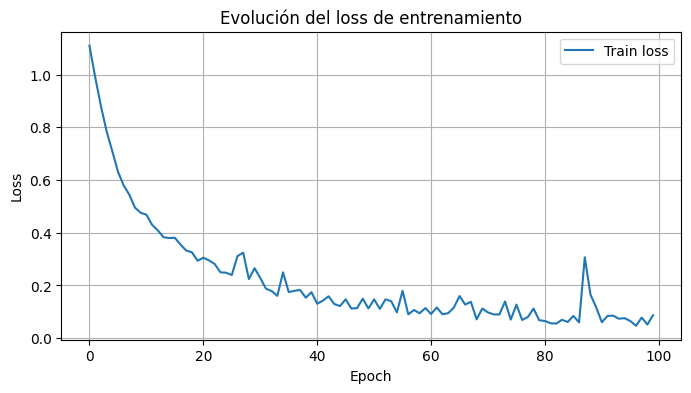

In [16]:
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = IrisMLP(hidden_dim=16).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

train_losses = []
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_dataloader)
    train_losses.append(epoch_train_loss)
    print(f"Epoch {epoch+1:03d}/{num_epochs} - Train loss: {epoch_train_loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolución del loss de entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

# Ejercicio 2

Antes de finalizar cada epoch, obtén el loss de validación. Haz otra gráfica que muestre ambos losses. Interpreta la gráfica.

Epoch 001/100 - Train loss: 1.2111 - Val loss: 1.0291
Epoch 002/100 - Train loss: 0.9815 - Val loss: 0.8544
Epoch 003/100 - Train loss: 0.9461 - Val loss: 0.8187
Epoch 004/100 - Train loss: 0.7534 - Val loss: 0.9894
Epoch 005/100 - Train loss: 0.6938 - Val loss: 0.7002
Epoch 006/100 - Train loss: 0.5867 - Val loss: 0.7242
Epoch 007/100 - Train loss: 0.5138 - Val loss: 0.5836
Epoch 008/100 - Train loss: 0.4775 - Val loss: 0.5478
Epoch 009/100 - Train loss: 0.4605 - Val loss: 0.5227
Epoch 010/100 - Train loss: 0.4222 - Val loss: 0.6198
Epoch 011/100 - Train loss: 0.3860 - Val loss: 0.5540
Epoch 012/100 - Train loss: 0.3839 - Val loss: 0.4797
Epoch 013/100 - Train loss: 0.3583 - Val loss: 0.4632
Epoch 014/100 - Train loss: 0.3141 - Val loss: 0.7077
Epoch 015/100 - Train loss: 0.3199 - Val loss: 0.4194
Epoch 016/100 - Train loss: 0.3361 - Val loss: 0.5449
Epoch 017/100 - Train loss: 0.3554 - Val loss: 0.5235
Epoch 018/100 - Train loss: 0.2864 - Val loss: 0.3839
Epoch 019/100 - Train loss: 

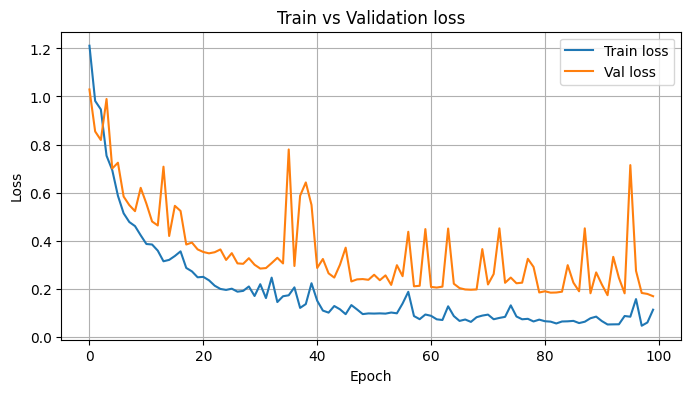

Interpretación: no se observan señales claras de sobreajuste.


In [17]:
model = IrisMLP(hidden_dim=16).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

train_losses = []
val_losses = []
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_dataloader)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(val_dataloader)
    val_losses.append(epoch_val_loss)

    print(
        f"Epoch {epoch+1:03d}/{num_epochs} - "
        f"Train loss: {epoch_train_loss:.4f} - Val loss: {epoch_val_loss:.4f}"
    )

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation loss")
plt.legend()
plt.grid(True)
plt.show()

if val_losses[-1] > min(val_losses) + 0.05:
    print("Interpretación: hay señales de sobreajuste en las últimas epochs.")
else:
    print("Interpretación: no se observan señales claras de sobreajuste.")

# Ejercicio 3

Escoge una de estas dos opciones:
- Implementa early stopping con X epochs de paciencia.
- Implementa un mecanismo de guardar el mejor modelo y monitorización del loss de validación durante el entrenamiento.

**Nota.** Para guardar y restaurar el estado de la red:
```python
best_state = copy.deepcopy(model.state_dict())
model.load_state_dict(best_state)
```

### Ejercicio 3 - Opción 1: Early Stopping con paciencia

In [18]:
model = IrisMLP(hidden_dim=16).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

num_epochs = 150
patience = 10
min_delta = 1e-4

best_val_loss = float("inf")
best_state = copy.deepcopy(model.state_dict())
epochs_without_improve = 0

train_losses_es = []
val_losses_es = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_dataloader)
    train_losses_es.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(val_dataloader)
    val_losses_es.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss - min_delta:
        best_val_loss = epoch_val_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1

    print(
        f"[ES] Epoch {epoch+1:03d}/{num_epochs} - "
        f"Train: {epoch_train_loss:.4f} - Val: {epoch_val_loss:.4f} - "
        f"NoImprove: {epochs_without_improve}/{patience}"
    )

    if epochs_without_improve >= patience:
        print(f"Early stopping activado en epoch {epoch+1}.")
        break

model.load_state_dict(best_state)
print(f"Modelo restaurado (mejor val loss): {best_val_loss:.4f}")

[ES] Epoch 001/150 - Train: 0.8569 - Val: 0.7133 - NoImprove: 0/10
[ES] Epoch 002/150 - Train: 0.6734 - Val: 0.7919 - NoImprove: 1/10
[ES] Epoch 003/150 - Train: 0.5786 - Val: 0.6233 - NoImprove: 0/10
[ES] Epoch 004/150 - Train: 0.5309 - Val: 0.6090 - NoImprove: 0/10
[ES] Epoch 005/150 - Train: 0.4665 - Val: 0.5443 - NoImprove: 0/10
[ES] Epoch 006/150 - Train: 0.4549 - Val: 0.5125 - NoImprove: 0/10
[ES] Epoch 007/150 - Train: 0.4157 - Val: 0.5955 - NoImprove: 1/10
[ES] Epoch 008/150 - Train: 0.3939 - Val: 0.5680 - NoImprove: 2/10
[ES] Epoch 009/150 - Train: 0.3872 - Val: 0.4627 - NoImprove: 0/10
[ES] Epoch 010/150 - Train: 0.3898 - Val: 0.4607 - NoImprove: 0/10
[ES] Epoch 011/150 - Train: 0.3500 - Val: 0.5009 - NoImprove: 1/10
[ES] Epoch 012/150 - Train: 0.3491 - Val: 0.5388 - NoImprove: 2/10
[ES] Epoch 013/150 - Train: 0.4508 - Val: 0.4141 - NoImprove: 0/10
[ES] Epoch 014/150 - Train: 0.3149 - Val: 0.4941 - NoImprove: 1/10
[ES] Epoch 015/150 - Train: 0.2820 - Val: 0.4299 - NoImprove: 

### Ejercicio 3 - Opción 2: Guardar mejor modelo + monitorización de loss de validación

[BM] Epoch 001/150 - Train: 1.2994 - Val: 1.0232 - Best val: 1.0232
[BM] Epoch 002/150 - Train: 0.9455 - Val: 1.0685 - Best val: 1.0232
[BM] Epoch 003/150 - Train: 0.8874 - Val: 0.7871 - Best val: 0.7871
[BM] Epoch 004/150 - Train: 0.7845 - Val: 0.7668 - Best val: 0.7668
[BM] Epoch 005/150 - Train: 0.6891 - Val: 0.7388 - Best val: 0.7388
[BM] Epoch 006/150 - Train: 0.6298 - Val: 0.6884 - Best val: 0.6884
[BM] Epoch 007/150 - Train: 0.5463 - Val: 0.6969 - Best val: 0.6884
[BM] Epoch 008/150 - Train: 0.5130 - Val: 0.6009 - Best val: 0.6009
[BM] Epoch 009/150 - Train: 0.4699 - Val: 0.5845 - Best val: 0.5845
[BM] Epoch 010/150 - Train: 0.4556 - Val: 0.6783 - Best val: 0.5845
[BM] Epoch 011/150 - Train: 0.4249 - Val: 0.5227 - Best val: 0.5227
[BM] Epoch 012/150 - Train: 0.3978 - Val: 0.4870 - Best val: 0.4870
[BM] Epoch 013/150 - Train: 0.3878 - Val: 0.6299 - Best val: 0.4870
[BM] Epoch 014/150 - Train: 0.3526 - Val: 0.4716 - Best val: 0.4716
[BM] Epoch 015/150 - Train: 0.3390 - Val: 0.4629

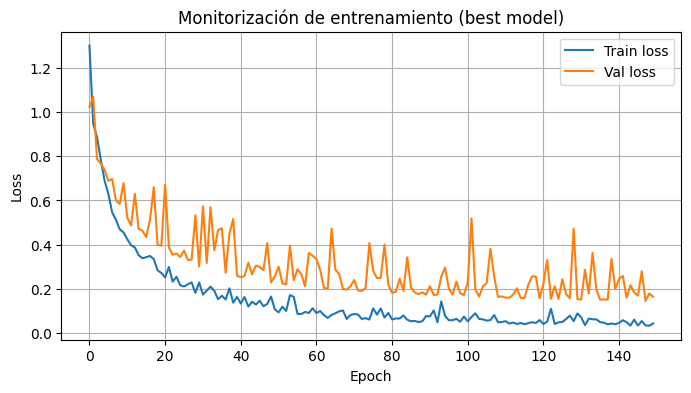

In [19]:
import matplotlib.pyplot as plt

model_bm = IrisMLP(hidden_dim=16).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_bm.parameters(), lr=0.05)

num_epochs = 150
best_val_loss_bm = float("inf")
best_state_bm = copy.deepcopy(model_bm.state_dict())

train_losses_bm = []
val_losses_bm = []

for epoch in range(num_epochs):
    model_bm.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model_bm(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_dataloader)
    train_losses_bm.append(epoch_train_loss)

    model_bm.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model_bm(X_batch)
            loss = criterion(logits, y_batch)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(val_dataloader)
    val_losses_bm.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss_bm:
        best_val_loss_bm = epoch_val_loss
        best_state_bm = copy.deepcopy(model_bm.state_dict())

    print(
        f"[BM] Epoch {epoch+1:03d}/{num_epochs} - "
        f"Train: {epoch_train_loss:.4f} - Val: {epoch_val_loss:.4f} - "
        f"Best val: {best_val_loss_bm:.4f}"
    )

model_bm.load_state_dict(best_state_bm)
print(f"Mejor modelo restaurado (BM) con val loss = {best_val_loss_bm:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_losses_bm, label="Train loss")
plt.plot(val_losses_bm, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Monitorización de entrenamiento (best model)")
plt.legend()
plt.grid(True)
plt.show()

# Ejercicio 4

Evalúa la mejor red obtenida en el apartado anterior. Usa `accuracy` como métrica.

In [20]:
def evaluate_accuracy(loader, model, device):
    model.eval()
    total = 0
    correct = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            preds = torch.argmax(logits, dim=1)

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return 100.0 * correct / total

accuracy = evaluate_accuracy(test_dataloader, model, device)
print(f"Accuracy en el conjunto de test: {accuracy:.2f}%")

Accuracy en el conjunto de test: 93.33%


# Ejercicio 5

Aumenta la hidden dimension a 1024 e implementa algún método de regularización visto en clase ($L_1,L_2$ o dropout).
- [`nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html)
- [`weight_decay`](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html)
- Para $L_1$ hay que hacerla a mano, añadiendo la norma $L_1$ de los parámetros al loss.


### Ejercicio 5 - Método 1: Regularización L2 (weight_decay)

In [21]:
model_l2 = IrisMLP(hidden_dim=1024).to(device)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model_l2.parameters(),
    lr=0.05,
    weight_decay=1e-3,
    momentum=0.9,
)

num_epochs = 150
best_val_loss_l2 = float("inf")
best_state_l2 = copy.deepcopy(model_l2.state_dict())

for epoch in range(num_epochs):
    model_l2.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model_l2(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_dataloader)

    model_l2.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model_l2(X_batch)
            loss = criterion(logits, y_batch)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(val_dataloader)

    if epoch_val_loss < best_val_loss_l2:
        best_val_loss_l2 = epoch_val_loss
        best_state_l2 = copy.deepcopy(model_l2.state_dict())

model_l2.load_state_dict(best_state_l2)
acc_l2 = evaluate_accuracy(test_dataloader, model_l2, device)
print(f"L2 -> Best val loss: {best_val_loss_l2:.4f} | Test acc: {acc_l2:.2f}%")

L2 -> Best val loss: 0.1135 | Test acc: 93.33%


### Ejercicio 5 - Método 2: Regularización L1 (añadida al loss)

In [22]:
model_l1 = IrisMLP(hidden_dim=1024).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_l1.parameters(), lr=0.05, momentum=0.9)

num_epochs = 150
l1_lambda = 1e-6
best_val_loss_l1 = float("inf")
best_state_l1 = copy.deepcopy(model_l1.state_dict())

for epoch in range(num_epochs):
    model_l1.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model_l1(X_batch)
        ce_loss = criterion(logits, y_batch)
        l1_penalty = sum(param.abs().sum() for param in model_l1.parameters())
        loss = ce_loss + l1_lambda * l1_penalty
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    model_l1.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model_l1(X_batch)
            val_loss = criterion(logits, y_batch)
            running_val_loss += val_loss.item()

    epoch_val_loss = running_val_loss / len(val_dataloader)
    if epoch_val_loss < best_val_loss_l1:
        best_val_loss_l1 = epoch_val_loss
        best_state_l1 = copy.deepcopy(model_l1.state_dict())

model_l1.load_state_dict(best_state_l1)
acc_l1 = evaluate_accuracy(test_dataloader, model_l1, device)
print(f"L1 -> Best val loss: {best_val_loss_l1:.4f} | Test acc: {acc_l1:.2f}%")

L1 -> Best val loss: 0.1058 | Test acc: 93.33%


### Ejercicio 5 - Método 3: Dropout

In [23]:
class IrisMLPDropout(nn.Module):
    def __init__(self, hidden_dim=1024, p=0.5):
        super().__init__()
        self.fc1 = nn.Linear(4, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=p)
        self.fc2 = nn.Linear(hidden_dim, 3)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model_do = IrisMLPDropout(hidden_dim=1024, p=0.5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_do.parameters(), lr=0.05, momentum=0.9)

num_epochs = 150
best_val_loss_do = float("inf")
best_state_do = copy.deepcopy(model_do.state_dict())

for epoch in range(num_epochs):
    model_do.train()

    for X_batch, y_batch in train_dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model_do(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

    model_do.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model_do(X_batch)
            val_loss = criterion(logits, y_batch)
            running_val_loss += val_loss.item()

    epoch_val_loss = running_val_loss / len(val_dataloader)
    if epoch_val_loss < best_val_loss_do:
        best_val_loss_do = epoch_val_loss
        best_state_do = copy.deepcopy(model_do.state_dict())

model_do.load_state_dict(best_state_do)
acc_do = evaluate_accuracy(test_dataloader, model_do, device)
print(f"Dropout -> Best val loss: {best_val_loss_do:.4f} | Test acc: {acc_do:.2f}%")

print("\nResumen Ejercicio 5:")
print(f"- L2:      val={best_val_loss_l2:.4f} | acc={acc_l2:.2f}%")
print(f"- L1:      val={best_val_loss_l1:.4f} | acc={acc_l1:.2f}%")
print(f"- Dropout: val={best_val_loss_do:.4f} | acc={acc_do:.2f}%")

Dropout -> Best val loss: 0.2771 | Test acc: 96.67%

Resumen Ejercicio 5:
- L2:      val=0.1135 | acc=93.33%
- L1:      val=0.1058 | acc=93.33%
- Dropout: val=0.2771 | acc=96.67%
